# Setup

## Installs

In [1]:
!pip install rsatoolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.7/734.7 kB 3.1 MB/s eta 0:00:00


## Imports

In [2]:
import numpy as np
import rsatoolbox
from tqdm.autonotebook import tqdm
import itertools

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

/tmp/ipykernel_28939/4003351230.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Functions

In [31]:
def create_filepaths_dict_from_folder(folder_path):
    """
    Creates a dictionary of .npy or .npz file paths from a given folder.

    Args:
        folder_path (str): The path to the folder containing .npy or .npz files.

    Returns:
        dict: A dictionary where keys are filenames (without extension) and values are full file paths.
    """
    filepaths_dict = {}
    for filename in os.listdir(folder_path):
        if filename.endswith(('.npy', '.npz')):
            key = os.path.splitext(filename)[0]
            full_filepath = os.path.join(folder_path, filename)
            filepaths_dict[key] = full_filepath
    return filepaths_dict

In [32]:
def load_features_dict(filepaths_dict):
    """
    Loads multiple .npy files from a dictionary of filepaths.

    Args:
        filepaths_dict (dict): A dictionary where keys are filenames (without extension) and values are full file paths.

    Returns:
        dict: A dictionary of loaded numpy arrays, with keys matching filepaths_dict.
    """
    features_dict = {}
    for key, filepath in tqdm(filepaths_dict.items()):
        features_dict[key] = np.load(filepath)
        if filepath.endswith('.npz'): # For .npz files, get the representations
            features_dict[key] = features_dict[key]['representations']
    return features_dict

In [33]:
def load_rdm(features, rdm_method, image_ids=None):
    if image_ids is not None:
        features = features[image_ids]
    dataset = rsatoolbox.data.Dataset(features)
    rdm = rsatoolbox.rdm.calc_rdm(dataset, method=rdm_method)
    return rdm

In [34]:
def load_rdm_dict(features_dict, rdm_method, image_ids=None):
    rdm_dict = {}
    for key, features in tqdm(features_dict.items()):
        rdm_dict[key] = load_rdm(features, rdm_method, image_ids=image_ids)
    return rdm_dict

In [35]:
def rsa(rdm_a, rdm_b, rsa_method):
    similarity_info = rsatoolbox.rdm.compare(rdm_a, rdm_b, method=rsa_method)
    return similarity_info[0][0], similarity_info

In [36]:
def compute_all_rsa_combinations(rdms_dict, keys, rsa_method):
    """
    Computes RSA between all unique combinations of RDMs in a list of keys.

    Args:
        rdms_dict (dict): A dictionary where keys are RDM identifiers and values are rsatoolbox.rdm.RDMs objects.
        keys (list): List of keys from the rdms_dict to consider for the combinations.
        rsa_method (str): The method to use for RSA calculation (e.g., 'rho-a').

    Returns:
        dict: A dictionary where keys are strings representing the RDM pair (e.g., 'RDM_A_vs_RDM_B')
              and values are the similarity scores.
    """
    rsa_results = {}
    # Calculate total combinations for tqdm
    total_combinations = len(keys) * (len(keys) - 1) // 2

    # Get all unique combinations of two RDMs (avoiding A-B and B-A, and A-A)
    for rdm_key_a, rdm_key_b in tqdm(itertools.combinations(keys, 2), total=total_combinations, desc="Computing RSA combinations"):
        rdm_a = rdms_dict[rdm_key_a]
        rdm_b = rdms_dict[rdm_key_b]

        similarity, _ = rsa(rdm_a, rdm_b, rsa_method=rsa_method)
        pair_name = f"{rdm_key_a}_vs_{rdm_key_b}"
        rsa_results[pair_name] = similarity

    return rsa_results

In [47]:
def visualize_rsa_matrix(rsa_results, rdm_keys, experiment_name):
    """
    Visualizes RSA results as a symmetric matrix.

    Args:
        rsa_results (dict): A dictionary of RSA similarity scores from compute_all_rsa_combinations.
                            Keys are 'RDM_A_vs_RDM_B', values are similarity scores.
        rdm_keys (list): A list of the keys used for the RDMs (e.g., ['A', 'B', 'C']).
        experiment_name (str): The name of the experiment for the plot title/colorbar label.
    """
    n_rdms = len(rdm_keys)
    # Initialize an empty matrix with 1s on the diagonal (RDM vs itself)
    rsa_matrix = np.identity(n_rdms)

    # Create a mapping from key to index
    key_to_idx = {key: i for i, key in enumerate(rdm_keys)}

    # Fill the upper and lower triangles of the matrix
    for pair_name, similarity_score in rsa_results.items():
        parts = pair_name.split('_vs_')
        if len(parts) == 2:
            key_a, key_b = parts[0], parts[1]
            idx_a = key_to_idx[key_a]
            idx_b = key_to_idx[key_b]
            rsa_matrix[idx_a, idx_b] = similarity_score
            rsa_matrix[idx_b, idx_a] = similarity_score # Ensure symmetry
        else:
            print(f"Warning: Could not parse pair name {pair_name}")

    # Convert to DataFrame for better heatmap labeling
    rsa_df = pd.DataFrame(rsa_matrix, index=rdm_keys, columns=rdm_keys)

    plt.figure(figsize=(n_rdms * 0.8, n_rdms * 0.7))
    sns.heatmap(rsa_df, annot=True, cmap='viridis', fmt=".2f",
                linewidths=.5, cbar_kws={'label': experiment_name})
    plt.title(f'RSA Similarity Matrix ({experiment_name})')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [42]:
def save_rdm_to_filepath(rdm, filepath):
    """
    Saves an RDM object to a specified filepath.

    Args:
        rdm (rsatoolbox.rdm.RDMs): The RDM object to save.
        filepath (str): The path to the file where the RDM will be saved (e.g., 'my_rdm.hdf5').
    """
    # Use the built-in save method of the RDMs object
    rdm.save(filepath, file_type='hdf5')
    print(f"RDM successfully saved to {filepath}")

In [39]:
def save_rdms_to_folder(rdm_dict, folder_path, rdm_method, suffix=None):
    """
    Saves all RDM objects from a dictionary to a designated folder.

    Args:
        rdm_dict (dict): A dictionary where keys are RDM identifiers
                         and values are rsatoolbox.rdm.RDMs objects.
        folder_path (str): The path to the folder where RDMs will be saved.
        rdm_method (str): The method used for RDM calculation (for filename).
        suffix (str, optional): An optional string to append to the filename.
    """
    os.makedirs(folder_path, exist_ok=True)
    for key, rdm in tqdm(rdm_dict.items(), desc="Saving RDMs"):
        # Construct filename: key_method_length_suffix.hdf5
        if suffix:
            filename = f"{key}_{rdm_method}_{rdm.n_cond}_{suffix}.hdf5"
        else:
            filename = f"{key}_{rdm_method}_{rdm.n_cond}.hdf5"
        filepath = os.path.join(folder_path, filename)
        save_rdm_to_filepath(rdm, filepath)

In [58]:
def load_rdms_from_folder(folder_path, filter_rdm_method=None, filter_n_cond=None, filter_suffix=None):
    """
    Loads RDM objects from .hdf5 files in a specified folder, with optional filtering.

    The filenames are expected to be in the format:
    'key_rdmMethod_nCond.hdf5' or 'key_rdmMethod_nCond_suffix.hdf5'

    Args:
        folder_path (str): The path to the folder containing RDM .hdf5 files.
        filter_rdm_method (str, optional): If provided, only loads RDMs matching this method.
        filter_n_cond (int, optional): If provided, only loads RDMs with this number of conditions.
        filter_suffix (str, optional): If provided, only loads RDMs matching this suffix.
                                        Use None to match files *without* a suffix.

    Returns:
        dict: A dictionary where keys are the extracted RDM names (first component
              of the filename) and values are rsatoolbox.rdm.RDMs objects.
    """
    loaded_rdms = {}
    for filename in tqdm(os.listdir(folder_path), desc=f"Loading RDMs from {folder_path}"):
        if not filename.endswith(".hdf5"):
            continue

        base_filename = os.path.splitext(filename)[0]

        extracted_key = None
        extracted_rdm_method = None
        extracted_n_cond = None
        extracted_suffix = None

        # Attempt to parse with suffix: key_Method_Ncond_Suffix
        parts_with_suffix = base_filename.rsplit('_', 3)
        if len(parts_with_suffix) == 4:
            try:
                temp_n_cond = int(parts_with_suffix[-2])
                extracted_key = '_'.join(parts_with_suffix[:-3])
                extracted_rdm_method = parts_with_suffix[-3]
                extracted_n_cond = temp_n_cond
                extracted_suffix = parts_with_suffix[-1]
            except ValueError:
                pass

        if extracted_key is None:
            parts_no_suffix = base_filename.rsplit('_', 2)
            if len(parts_no_suffix) == 3:
                try:
                    temp_n_cond = int(parts_no_suffix[-1])
                    extracted_key = '_'.join(parts_no_suffix[:-2])
                    extracted_rdm_method = parts_no_suffix[-2]
                    extracted_n_cond = temp_n_cond
                    extracted_suffix = None
                except ValueError:
                    continue
            else:
                continue

        if filter_rdm_method is not None and extracted_rdm_method != filter_rdm_method:
            continue
        if filter_n_cond is not None and extracted_n_cond != filter_n_cond:
            continue
        if filter_suffix is None and extracted_suffix is not None:
            continue
        if filter_suffix is not None and extracted_suffix != filter_suffix:
            continue

        full_filepath = os.path.join(folder_path, filename)
        try:
            # Use the correct method to load RDMs
            rdm = rsatoolbox.rdm.load_rdm(full_filepath)
            loaded_rdms[extracted_key] = rdm
        except Exception as e:
            print(f"Error loading RDM from {filename}: {e}")
            continue

    return loaded_rdms

# Settings

In [46]:
# Mount google drive for getting the data
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
platonics_data_folder_path = '/content/drive/MyDrive/YOUR_PARTICULAR_PATH_HERE/Neuromatch NeuroAI Longma Karashi 1/data'
diffusion_folder_path = os.path.join(platonics_data_folder_path, 'diffusion features')
monkeys_folder_path = os.path.join(platonics_data_folder_path, 'processed')
rdms_folder_path = os.path.join(platonics_data_folder_path, 'rdms')
do_load_rdms_from_folder = True

metadata_file_path = os.path.join(monkeys_folder_path, "things_metadata_subset.csv")
metadata_df = pd.read_csv(metadata_file_path)
image_ids = np.unique(metadata_df['image_id'].to_numpy()) # Identifiers/indices of the images to use. "np.arange(22248)" to use all of them (RDM computations will get slow)
filter_name = "OneImgPerClass" # The things_metadata_subset.csv has one image per class
print(f"{len(image_ids)} images will be used")

rdm_method = "correlation"
rsa_method = "rho-a"

experiment_name = f"rdm={rdm_method}_rsa={rsa_method}_filter={filter_name}"
print(f"Experiment name: {experiment_name}")

1854 images will be used
Experiment name: rdm=correlation_rsa=rho-a_filter=OneImgPerClass


# Experiments

In [11]:
diffusion_filepaths_dict = create_filepaths_dict_from_folder(diffusion_folder_path)
monkeys_filepaths_dict = create_filepaths_dict_from_folder(monkeys_folder_path)

filepaths_dict = diffusion_filepaths_dict
filepaths_dict.update(monkeys_filepaths_dict)

In [60]:
if do_load_rdms_from_folder:
    rdm_dict = load_rdms_from_folder(rdms_folder_path, filter_rdm_method=rdm_method, filter_n_cond=len(image_ids), filter_suffix=filter_name)
else:
    features_dict = load_features_dict(filepaths_dict)
    rdm_dict = load_rdm_dict(features_dict, rdm_method=rdm_method, image_ids=image_ids)

print(f"Loaded RDMs: {sorted(rdm_dict.keys())}")

Loading RDMs from /content/drive/MyDrive/Actividades/Propósito/Formación/2026_Neuromatch_NeuroAI/Neuromatch …

Loaded RDMs: ['monkeyF_IT_train_responses', 'monkeyF_V1_train_responses', 'monkeyF_V4_train_responses', 'monkeyN_IT_train_responses', 'monkeyN_V1_train_responses', 'monkeyN_V4_train_responses', 'sd_mid_block_0.01', 'sd_mid_block_0.05', 'sd_mid_block_0.10', 'sd_mid_block_0.15', 'sd_mid_block_0.20', 'sd_mid_block_0.25', 'sd_mid_block_0.30', 'sd_mid_block_0.35', 'sd_mid_block_0.40', 'sd_mid_block_0.45', 'sd_mid_block_0.50', 'sd_mid_block_0.55', 'sd_mid_block_0.60', 'sd_mid_block_0.65', 'sd_mid_block_0.70', 'sd_mid_block_0.75', 'sd_mid_block_0.80', 'sd_mid_block_0.85', 'sd_mid_block_0.90', 'sd_mid_block_0.95', 'sd_mid_block_0.99']


In [61]:
#all_keys = filepaths_dict.keys() # All to all comparison (remember that the number of comparisons scales quadratically)
custom_keys = list(monkeys_filepaths_dict.keys()) + [f"sd_mid_block_{noise:.2f}" for noise in [0.01, 0.25, 0.5, 0.75, 0.99]]
rsa_results = compute_all_rsa_combinations(rdm_dict, custom_keys, rsa_method)

Computing RSA combinations:   0%|          | 0/55 [00:00<?, ?it/s]

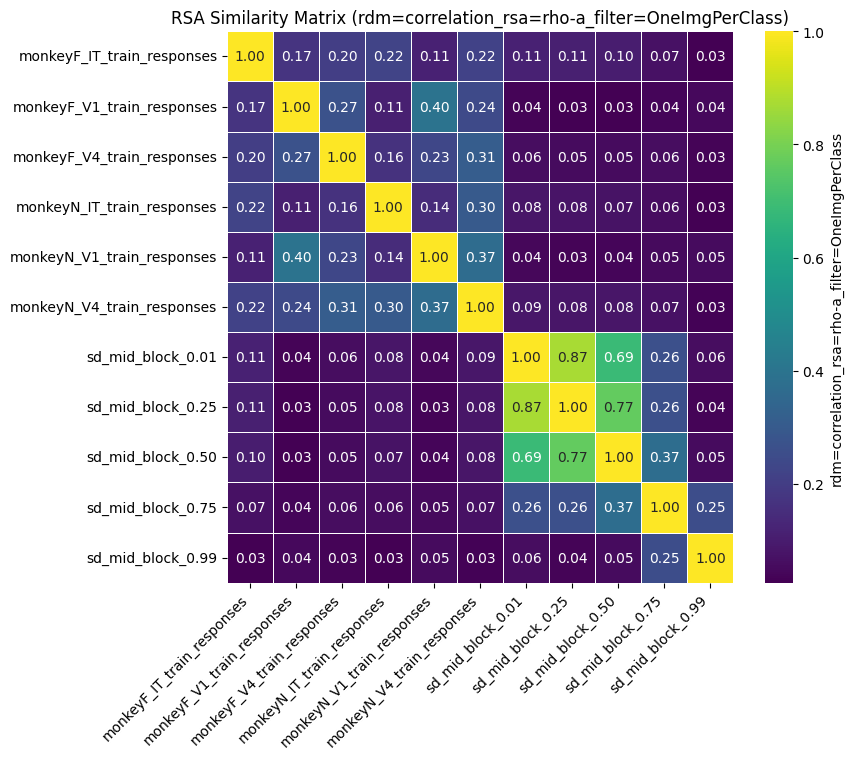

In [62]:
visualize_rsa_matrix(rsa_results, sorted(custom_keys), experiment_name)

In [43]:
save_rdms_to_folder(rdm_dict, rdms_folder_path, rdm_method, suffix=filter_name)

Saving RDMs:   0%|          | 0/27 [00:00<?, ?it/s]

RDM successfully saved to /content/drive/MyDrive/Actividades/Propósito/Formación/2026_Neuromatch_NeuroAI/Neuromatch NeuroAI Longma Karashi 1/data/rdms/sd_mid_block_0.50_correlation_1854_OneImgPerClass.hdf5
RDM successfully saved to /content/drive/MyDrive/Actividades/Propósito/Formación/2026_Neuromatch_NeuroAI/Neuromatch NeuroAI Longma Karashi 1/data/rdms/sd_mid_block_0.55_correlation_1854_OneImgPerClass.hdf5
RDM successfully saved to /content/drive/MyDrive/Actividades/Propósito/Formación/2026_Neuromatch_NeuroAI/Neuromatch NeuroAI Longma Karashi 1/data/rdms/sd_mid_block_0.90_correlation_1854_OneImgPerClass.hdf5
RDM successfully saved to /content/drive/MyDrive/Actividades/Propósito/Formación/2026_Neuromatch_NeuroAI/Neuromatch NeuroAI Longma Karashi 1/data/rdms/sd_mid_block_0.80_correlation_1854_OneImgPerClass.hdf5
RDM successfully saved to /content/drive/MyDrive/Actividades/Propósito/Formación/2026_Neuromatch_NeuroAI/Neuromatch NeuroAI Longma Karashi 1/data/rdms/sd_mid_block_0.

In [ ]:
# Legacy code for computing and individual RSA and visualizing RDMs
"""
similarity, similarity_info = rsa(rdm_dict["A"], rdm_dict["B"], rsa_method=rsa_method)
print(f"RSA Alignment Score ({rsa_method}): {similarity:.4f}")

rsatoolbox.vis.show_rdm(rdm_dict["A"])
rsatoolbox.vis.show_rdm(rdm_dict["B"])
"""